In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import ndimage

In [5]:
data_dir = "./Task-2"
image_path = os.path.join(data_dir, "AF1.jpg")

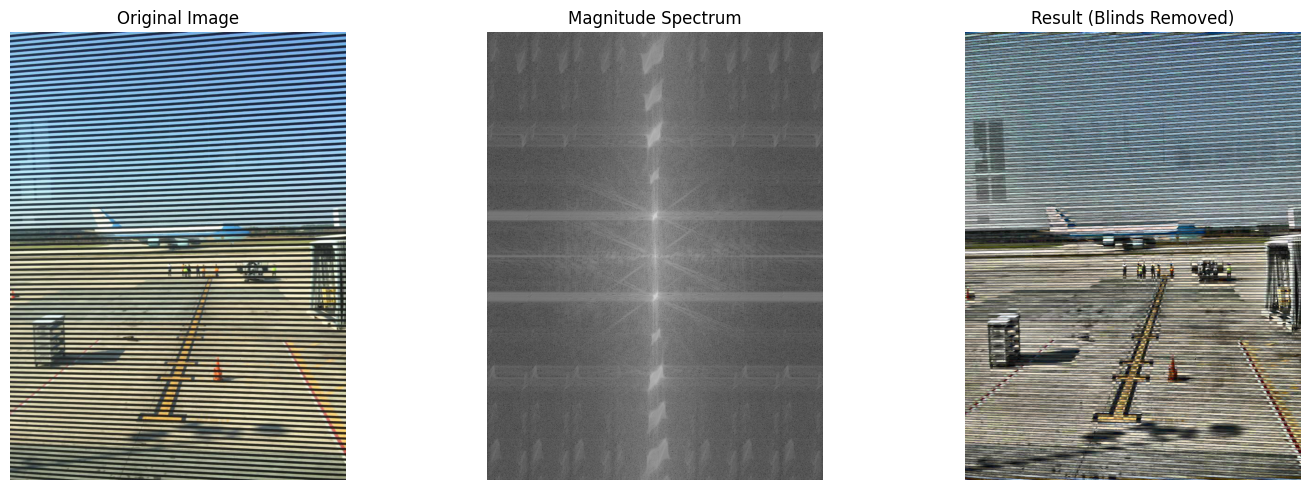

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def remove_blinds(image_path):
    # Read the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Process each color channel separately
    channels = []
    for channel in cv2.split(img):
        # Apply FFT
        f = np.fft.fft2(channel.astype(float))
        fshift = np.fft.fftshift(f)
        
        # Create a mask to remove horizontal frequencies
        rows, cols = channel.shape
        crow, ccol = rows//2, cols//2
        
        # Create the mask
        mask = np.ones((rows, cols), np.float32)
        
        # Remove horizontal stripes by zeroing out horizontal frequencies
        stripe_thickness = 5  # Adjust this value to control filtering strength
        for i in range(-20, 21):  # Adjust range to control how many harmonics to remove
            mask[crow + i-stripe_thickness:crow + i+stripe_thickness, :] = 0
            
        # Apply additional gaussian blur to the mask to avoid ringing
        mask = cv2.GaussianBlur(mask, (5,5), 0)
        
        # Apply mask
        fshift_filtered = fshift * mask
        
        # Inverse FFT
        f_ishift = np.fft.ifftshift(fshift_filtered)
        img_back = np.fft.ifft2(f_ishift)
        img_back = np.abs(img_back)
        
        # Normalize
        img_back = cv2.normalize(img_back, None, 0, 255, cv2.NORM_MINMAX)
        channels.append(img_back.astype(np.uint8))
    
    # Merge channels
    result = cv2.merge(channels)
    
    # Enhance the result
    # Convert to LAB color space for better enhancement
    lab = cv2.cvtColor(result, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # Apply CLAHE to L channel
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    
    # Merge back and convert to RGB
    lab = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Show magnitude spectrum for debugging
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))
    
    return img, magnitude_spectrum, enhanced

def plot_results(original, spectrum, result):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    ax1.imshow(original)
    ax1.set_title('Original Image')
    ax1.axis('off')
    
    ax2.imshow(spectrum, cmap='gray')
    ax2.set_title('Magnitude Spectrum')
    ax2.axis('off')
    
    ax3.imshow(result)
    ax3.set_title('Result (Blinds Removed)')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()

original, spectrum, result = remove_blinds(image_path)
plot_results(original, spectrum, result)